# Recherche du meilleur modele de ML a deployer pour optimisation du pricing retail.

En plus de la question ci-dessus, l'équipe Data Science travaille sur *l'optimisation des prix*. Ils ont collecté des données pour suggérer des prix optimaux pour les propriétaires de voitures en utilisant le Machine Learning

In [48]:
# import des librairies
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [26]:
#import des données
df_pricing = pd.read_csv('https://full-stack-assets.s3.eu-west-3.amazonaws.com/Deployment/get_around_pricing_project.csv')
df_pricing.head()

,Unnamed: 0,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


In [27]:
# definir la target et les features
target = df_pricing['rental_price_per_day']
features = df_pricing.drop(columns=['rental_price_per_day', 'Unnamed: 0'])

# modifier les colonnes booleene en int
bool_cols = features.select_dtypes(include=['bool']).columns
features[bool_cols] = features[bool_cols].astype(int)


In [28]:
# split des données en train et test
X = features
y = target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# creation du pipeline de preprocessing
numeric_features = X.select_dtypes(exclude=['object', 'bool']).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()
boolean_features = X.select_dtypes(include='bool').columns.tolist()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Boolean features:", boolean_features)


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('bool', 'passthrough', boolean_features)
    ])


Numeric features: ['mileage', 'engine_power', 'private_parking_available', 'has_gps', 'has_air_conditioning', 'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']
Categorical features: ['model_key', 'fuel', 'paint_color', 'car_type']
Boolean features: []


In [32]:
# baseline model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'Baseline Model R^2: {r2}')
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'Baseline Model MSE: {mse}')
print(f'Baseline Model MAE: {mae}')

Baseline Model R^2: 0.6937089186431302
Baseline Model MSE: 322.5930440632083
Baseline Model MAE: 12.115437865351666


- on a un R2 score de 69,37 % qui est acceptable.
- on a une erreur de + ou -12 Euros
- le MSE donne une interpretaition 322 soit la racine carré de 18 Euros. 

In [51]:
# on va gérer plusieurs modeles et sortir le meilleur, on va utiliser lasso et ridge aussi

models={
    'DecisionTreeRegressor': DecisionTreeRegressor(),
    'RandomForestRegressor': RandomForestRegressor(),
    'GradientBoostingRegressor': GradientBoostingRegressor(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'XGBRegressor': XGBRegressor(),
    'AdaboostRegressor': AdaBoostRegressor()
}

params = {
    'DecisionTreeRegressor': {'regressor__max_depth': [5, 10, 15]},
    'RandomForestRegressor': {'regressor__n_estimators': [50, 100], 'regressor__max_depth': [10, 20]},
    'GradientBoostingRegressor': {'regressor__n_estimators': [100, 200], 'regressor__learning_rate': [0.05, 0.1]},
    'Lasso': {'regressor__alpha': [0.1, 1.0, 10.0]},
    'Ridge': {'regressor__alpha': [0.1, 1.0, 10.0]},
    'XGBRegressor': {'regressor__n_estimators': [100, 200], 'regressor__learning_rate': [0.05, 0.1]},
    'AdaboostRegressor': {'regressor__n_estimators': [50, 100], 'regressor__learning_rate': [0.05, 0.1]}
}


results = {}


for model_name, model_instance in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model_instance)
    ])
    
    # Hyperparameter tuning (simple grid search)
    from sklearn.model_selection import GridSearchCV
    grid_search = GridSearchCV(pipeline, params[model_name], cv=3, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results[model_name] = {
        'Best Parameters': grid_search.best_params_,
        'R2': r2,
        'MSE': mse,
        'MAE': mae
    }

In [52]:
# resultat sous dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='R2', ascending=False)
results_df

,Best Parameters,R2,MSE,MAE
XGBRegressor,"{'regressor__learning_rate': 0.05, 'regressor_...",0.74801,265.401611,10.491424
GradientBoostingRegressor,"{'regressor__learning_rate': 0.1, 'regressor__...",0.744246,269.365741,10.908428
RandomForestRegressor,"{'regressor__max_depth': 20, 'regressor__n_est...",0.725552,289.054945,10.826787
Ridge,{'regressor__alpha': 1.0},0.693485,322.828956,12.118296
Lasso,{'regressor__alpha': 0.1},0.678791,338.304752,12.321408
DecisionTreeRegressor,{'regressor__max_depth': 10},0.603151,417.971013,13.2675
AdaboostRegressor,"{'regressor__learning_rate': 0.05, 'regressor_...",0.555459,468.200976,15.222136


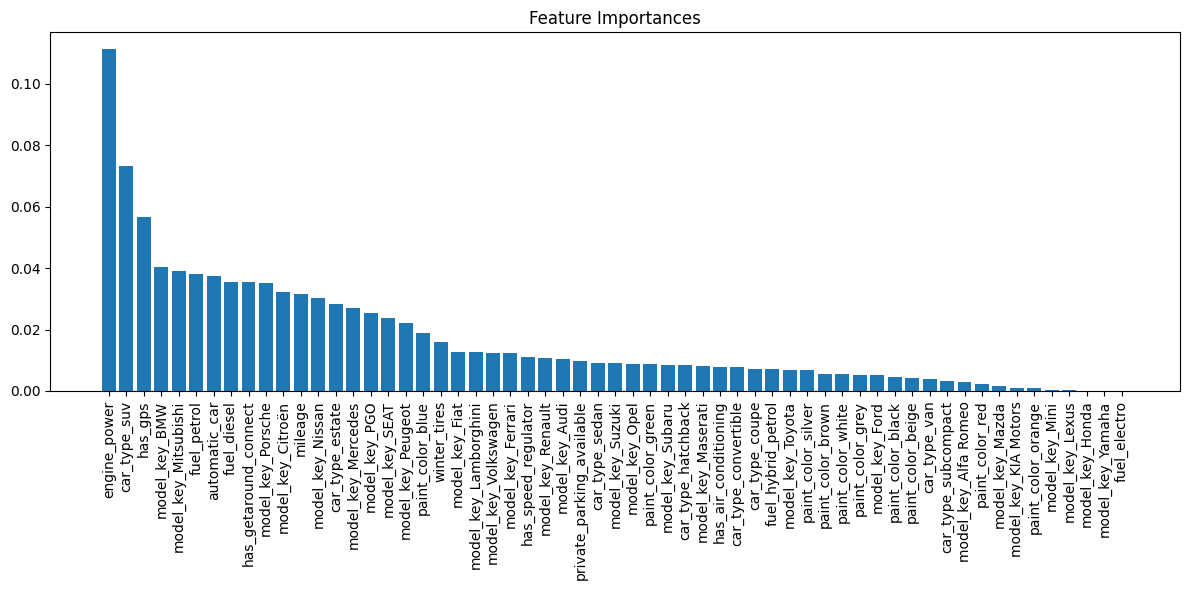

In [53]:
# constat de l'importance des feature visualisation graphique
best_model_name = results_df.index[0]
best_model_instance = models[best_model_name]
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', best_model_instance)
])
best_pipeline.fit(X_train, y_train)
import matplotlib.pyplot as plt
importances = best_pipeline.named_steps['regressor'].feature_importances_
features_names = numeric_features + list(best_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)) + boolean_features
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [features_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show() 

In [55]:
# donc le meilleur modele est 
best_pipeline

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
# sauvegarde du meilleur modele
import joblib

joblib.dump(best_pipeline, 'best_pricing_model.pkl')
print("Best pricing model saved as 'best_pricing_model.pkl'")


Best pricing model saved as 'best_pricing_model.pkl'
